In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r


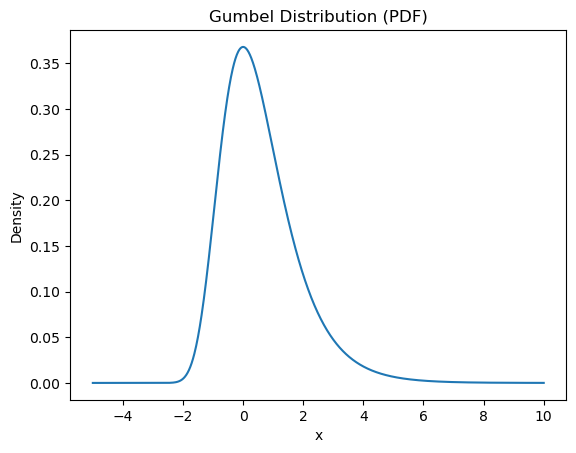

In [2]:
x = np.linspace(-5, 10, 1000)

mu = 0.0
beta = 1.0

pdf = gumbel_r.pdf(x, loc=mu, scale=beta)

plt.figure()
plt.plot(x, pdf)
plt.title("Gumbel Distribution (PDF)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


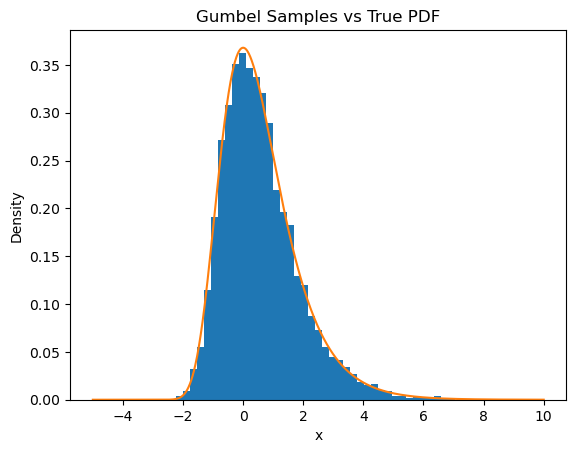

In [3]:
n = 10000
u = np.random.rand(n)
g_samples = -np.log(-np.log(u))

x = np.linspace(-5, 10, 1000)
pdf = gumbel_r.pdf(x)

plt.figure()
plt.hist(g_samples, bins=50, density=True)
plt.plot(x, pdf)
plt.title("Gumbel Samples vs True PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


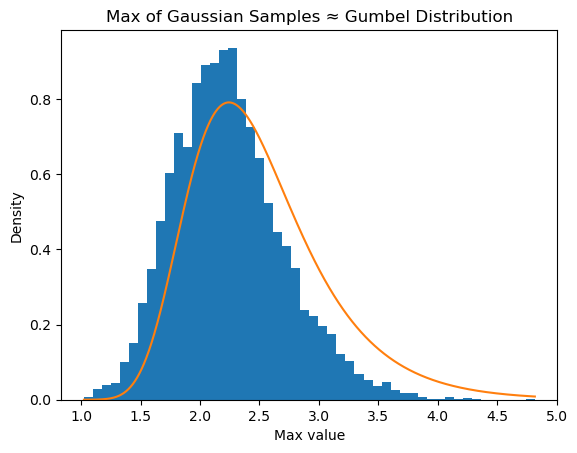

In [4]:
def sample_maxima(num_trials=5000, n_per_trial=50):
    maxima = []
    for _ in range(num_trials):
        xs = np.random.randn(n_per_trial)  # Gaussian samples
        maxima.append(xs.max())
    return np.array(maxima)

max_samples = sample_maxima()

x = np.linspace(min(max_samples), max(max_samples), 1000)
pdf = gumbel_r.pdf(x, loc=np.mean(max_samples), scale=np.std(max_samples))

plt.figure()
plt.hist(max_samples, bins=50, density=True)
plt.plot(x, pdf)
plt.title("Max of Gaussian Samples ≈ Gumbel Distribution")
plt.xlabel("Max value")
plt.ylabel("Density")
plt.show()


Logits: [ 2.   1.   0.1 -0.5]
Softmax probs: [0.6252 0.23   0.0935 0.0513]


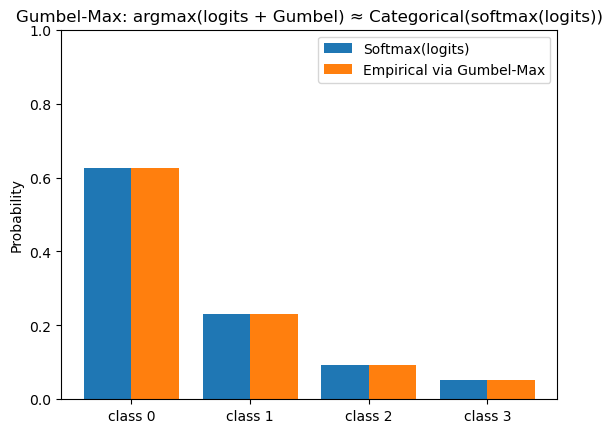

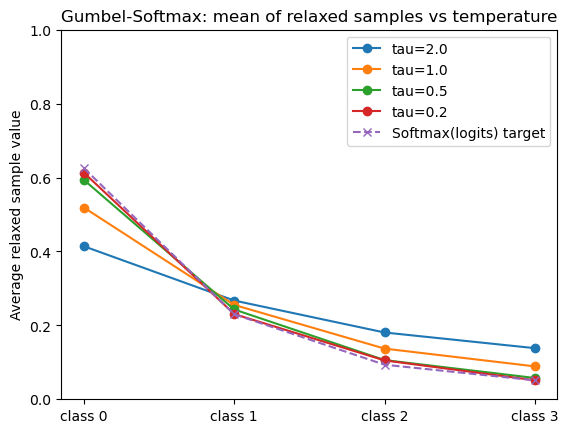

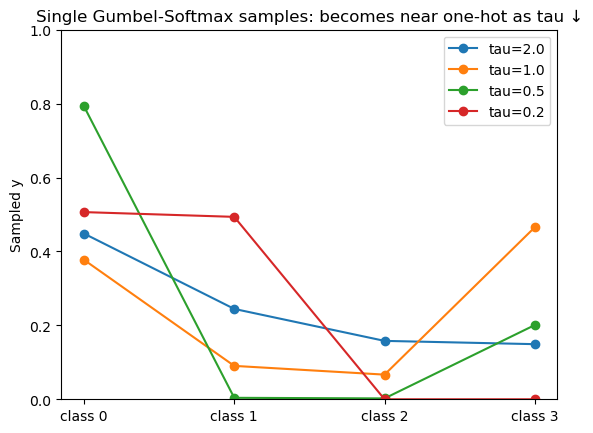

In [5]:
# --- Helpers ---
def softmax(logits):
    z = logits - np.max(logits)
    e = np.exp(z)
    return e / e.sum()

def sample_gumbel(shape, eps=1e-12):
    # Standard Gumbel(0,1): g = -log(-log(u))
    u = np.random.rand(*shape)
    return -np.log(-np.log(u + eps) + eps)

def gumbel_softmax_sample(logits, tau=1.0):
    g = sample_gumbel(logits.shape)
    y = softmax((logits + g) / tau)
    return y

# --- Demo settings ---
np.random.seed(0)

logits = np.array([2.0, 1.0, 0.1, -0.5])   # unnormalized log-probabilities
p = softmax(logits)

print("Logits:", logits)
print("Softmax probs:", np.round(p, 4))

# --- 1) Gumbel-Max trick: argmax(logits + g) samples from softmax(logits) ---
N = 200_000
g = sample_gumbel((N, len(logits)))
winners = np.argmax(logits[None, :] + g, axis=1)
emp = np.bincount(winners, minlength=len(logits)) / N

plt.figure()
x = np.arange(len(logits))
plt.bar(x - 0.2, p, width=0.4, label="Softmax(logits)")
plt.bar(x + 0.2, emp, width=0.4, label="Empirical via Gumbel-Max")
plt.xticks(x, [f"class {i}" for i in x])
plt.ylim(0, 1)
plt.title("Gumbel-Max: argmax(logits + Gumbel) ≈ Categorical(softmax(logits))")
plt.ylabel("Probability")
plt.legend()
plt.show()

# --- 2) Gumbel-Softmax (relaxation): show how temperature changes "one-hot-ness" ---
taus = [2.0, 1.0, 0.5, 0.2]
K = 5000

plt.figure()
for tau in taus:
    ys = np.array([gumbel_softmax_sample(logits, tau=tau) for _ in range(K)])
    # average relaxed sample should be close to softmax(logits) (for reasonable tau)
    avg = ys.mean(axis=0)
    plt.plot(x, avg, marker="o", label=f"tau={tau}")

plt.plot(x, p, linestyle="--", marker="x", label="Softmax(logits) target")
plt.xticks(x, [f"class {i}" for i in x])
plt.ylim(0, 1)
plt.title("Gumbel-Softmax: mean of relaxed samples vs temperature")
plt.ylabel("Average relaxed sample value")
plt.legend()
plt.show()

# --- 3) One illustrative sample per tau (shows sharpening as tau ↓) ---
plt.figure()
for tau in taus:
    y = gumbel_softmax_sample(logits, tau=tau)
    plt.plot(x, y, marker="o", label=f"tau={tau}")

plt.xticks(x, [f"class {i}" for i in x])
plt.ylim(0, 1)
plt.title("Single Gumbel-Softmax samples: becomes near one-hot as tau ↓")
plt.ylabel("Sampled y")
plt.legend()
plt.show()
